## User Story

As a power systems engineer designing a 48V DC bus for a telecom/BESS installation, I need to verify that my selected fuse will clear a bolted fault before the cable is damaged. Specifically: what is the peak fault current, how fast does it rise, and does the fault deliver enough I²t energy to melt the fuse element within the protection window?

# DC Bus Fault Current & Fuse Coordination

Determine the peak fault current on a 48V DC bus during a bolted short circuit at the load terminals, and verify the selected fuse clears before cable damage.

A bolted fault is the worst case — zero impedance short. The fault current is limited only by the source internal resistance, cable impedance, and fuse resistance. If the fuse I²t is less than the fault I²t, the fuse melts and clears the circuit. If not, the cable burns.

The hand calc uses a resistive-only model (ignores cable inductance). This overestimates the steady-state current since inductance only affects the transient rise. SPICE includes the inductance, showing the actual current waveform — slower rise, same steady state.

## Assumptions (hand calc / resistive model)
- Bolted fault (zero impedance short at load terminals)
- Resistive-only loop (cable inductance neglected)
- Constant bus voltage (battery source, no droop under fault)
- Cold fuse resistance (fuse hasn't heated yet)
- No arc resistance (worst case)
- Sea level, 25°C (no altitude or temperature derating)

In [2]:
# Symbolic derivation — fault current from Ohm's law
import sympy as sp

V_bus, R_src, R_fuse, R_cable, R_fault = sp.symbols(
    "V_bus R_src R_fuse R_cable R_fault", positive=True
)

R_total = R_src + R_fuse + R_cable + R_fault
I_fault = V_bus / R_total

print(f"Total loop resistance: R_total = {R_total}")
print(f"Fault current: I_fault = {I_fault}")

Total loop resistance: R_total = R_cable + R_fault + R_fuse + R_src
Fault current: I_fault = V_bus/(R_cable + R_fault + R_fuse + R_src)


In [3]:
# I²t for fuse coordination
t_fault = sp.Symbol("t_fault", positive=True)

# Reason: for constant current (resistive model), I²t = I² * t
i2t = I_fault**2 * t_fault
print(f"Fault I²t = {i2t}")
print("Fuse clears if: I²t_fault > I²t_fuse_melt")

Fault I²t = V_bus**2*t_fault/(R_cable + R_fault + R_fuse + R_src)**2
Fuse clears if: I²t_fault > I²t_fuse_melt


In [6]:
# Plug in actual values with pint + uncertainties
import pint
from uncertainties import ufloat

ureg = pint.UnitRegistry()

BUS_VOLTAGE = 48.0 * ureg.V
SOURCE_RESISTANCE = ufloat(5.0, 0.5) * ureg.mohm      # battery pack ±10%
FUSE_RESISTANCE = 1.0 * ureg.mohm                       # cold, per datasheet
CABLE_RESISTANCE = ufloat(8.0, 0.8) * ureg.mohm        # 4 AWG, 3m, ±10% per NEC Ch9 T8
FAULT_RESISTANCE = 0.1 * ureg.mohm                      # bolted short

TOTAL_R = (SOURCE_RESISTANCE + FUSE_RESISTANCE + CABLE_RESISTANCE + FAULT_RESISTANCE).to(ureg.mohm)
FAULT_CURRENT = (BUS_VOLTAGE / TOTAL_R).to(ureg.kA)

FUSE_I2T_MELT = ufloat(12000, 1200) * ureg.A**2 * ureg.s  # fuse datasheet ±10%
FAULT_DURATION = 10.0 * ureg.ms
FAULT_I2T = (FAULT_CURRENT**2 * FAULT_DURATION).to(ureg.A**2 * ureg.s)

print(f"Total loop resistance: {TOTAL_R}")
print(f"Peak fault current (resistive): {FAULT_CURRENT:.2f}")
print(f"Fault I²t at 10ms: {FAULT_I2T:.0f}")
print(f"Fuse melting I²t: {FUSE_I2T_MELT}")
print(f"\nFuse clears? {FAULT_I2T.magnitude.nominal_value > FUSE_I2T_MELT.magnitude.nominal_value}")
print(f"\nSPICE sim must show: current starts at 0, rises with L/R time constant, reaches ~{FAULT_CURRENT.magnitude.nominal_value:.1f} kA")

Total loop resistance: 14.1+/-0.9 milliohm
Peak fault current (resistive): 3.40+/-0.23 kiloampere
Fault I²t at 10ms: 115890+/-15508 ampere ** 2 * second
Fuse melting I²t: (1.20+/-0.12)e+04 ampere ** 2 * second

Fuse clears? True

SPICE sim must show: current starts at 0, rises with L/R time constant, reaches ~3.4 kA


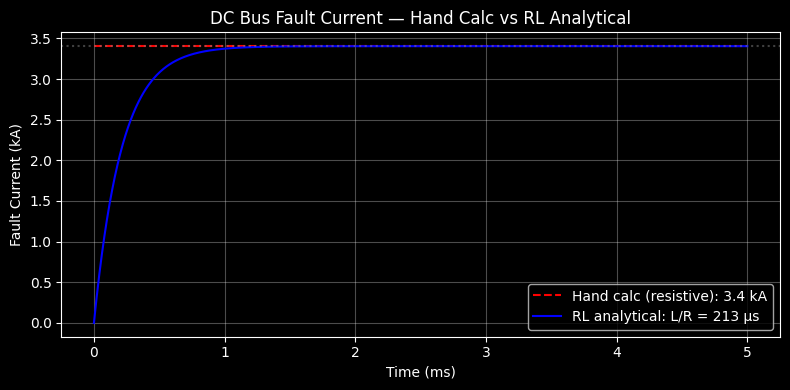

L/R time constant: 213 µs
SPICE sim will match the blue RL curve, not the red resistive step


In [7]:
# Verification plot — ideal (resistive) fault current vs time
import numpy as np
import matplotlib.pyplot as plt

i_fault_a = FAULT_CURRENT.to(ureg.A).magnitude.nominal_value
cable_l = 3e-6  # H
total_r = TOTAL_R.to(ureg.ohm).magnitude.nominal_value
tau_us = (cable_l / total_r) * 1e6  # L/R time constant in us

t_ms = np.linspace(0, 5, 1000)
t_s = t_ms / 1e3

# Reason: RL step response — i(t) = I_ss * (1 - exp(-t/tau))
i_ideal = np.full_like(t_ms, i_fault_a / 1e3)  # resistive: instant step to I_fault
i_rl = (i_fault_a * (1 - np.exp(-t_s / (cable_l / total_r)))) / 1e3  # with L

plt.figure(figsize=(8, 4))
plt.plot(t_ms, i_ideal, "r--", label=f"Hand calc (resistive): {i_fault_a/1e3:.1f} kA")
plt.plot(t_ms, i_rl, "b-", label=f"RL analytical: L/R = {tau_us:.0f} µs")
plt.axhline(i_fault_a / 1e3, color="gray", linestyle=":", alpha=0.5)
plt.xlabel("Time (ms)")
plt.ylabel("Fault Current (kA)")
plt.title("DC Bus Fault Current — Hand Calc vs RL Analytical")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sim/results/fault_current_analytical.png", dpi=150)
plt.show()

print(f"L/R time constant: {tau_us:.0f} µs")
print("SPICE sim will match the blue RL curve, not the red resistive step")

## Expected Values
- **Total loop resistance:** 14.1 +/- 0.94 mohm (propagated from source + cable tolerances)
- **Peak fault current (resistive):** 3.40 +/- 0.23 kA (V_bus / R_total, no inductance)
- **L/R time constant:** ~213 us (cable inductance / total resistance)
- **Fault I²t at 10ms:** ~116,000 A²·s (exceeds fuse melting I²t of 12,000 A²·s)
- **Fuse clears?** Yes — fault delivers ~10x the fuse melting energy
- **SPICE sim must show:** current starts at 0, rises with L/R tau ~213 us, reaches ~3.4 kA steady state